# Mesh resolution

In [1]:
from functools import partial
from lucifex.sim import parallel_run, as_grid_simulation
from lucifex.viz import (
    plot_colormap, plot_line, set_ipynb_variable, 
    save_figure, get_ipynb_file_name
)
from lucifex.utils.array_utils import as_index
from crocodil.dns.theory import threshold_rayleigh
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE

Nx_opts = (80, 120) # (120, 160, 180)
Ny_opts = (80, 120) # (120, 160, 180)
CELL_TYPE = 'quadrilateral'
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1
RA = 500.0

aspect = SYSTEM_A_REFERENCE['aspect']
Ra_thresh_min = threshold_rayleigh(aspect, 1.0, min(Nx_opts), 2)
Ra_thresh_max = threshold_rayleigh(aspect, 1.0, max(Nx_opts), 2)
print(f"Ra = {RA} , Ra_thresh_min = {Ra_thresh_min} ,  Ra_thresh_max = {Ra_thresh_max}")

n_proc = set_ipynb_variable('N_PROC', 3)
n_stop = set_ipynb_variable('N_STOP', 400)
dt_init = 1e-6
n_init = 10

STORE = 1
create_sim = dns_system_a(store_delta=STORE)

simulations = parallel_run(
    create_sim, n_proc, n_stop, 
    dt_init=dt_init, n_init=n_init,
    serialize=partial(as_grid_simulation, slc_func='::5', include=('c', 'cMinMax', 'uRMS', 'uMinMax')),
    link=True,
    max_nbytes=None,
    mmap_mode=None,
)(
    cell=CELL_TYPE,
    scaling='advective',
    **SYSTEM_A_REFERENCE.replace(Ra=RA),
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    c_stabilization=None,
    c_limits=True,
    diagnostic=True,
)(
    Nx=Nx_opts,
    Ny=Ny_opts,
)

Ra = 500.0 , Ra_thresh_min = 1800.0 ,  Ra_thresh_max = 2700.0


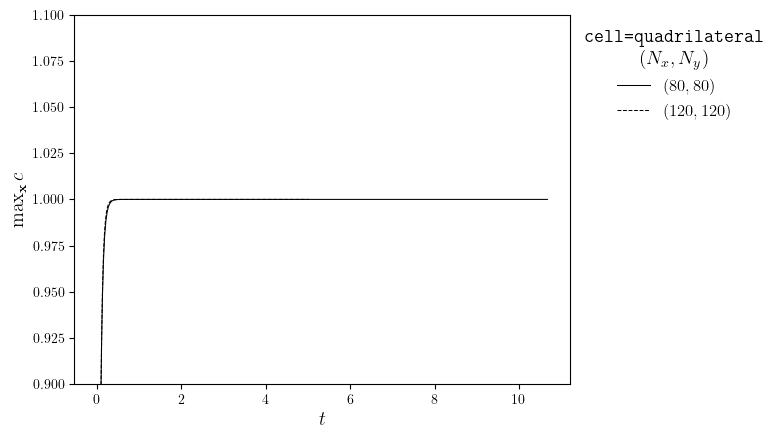

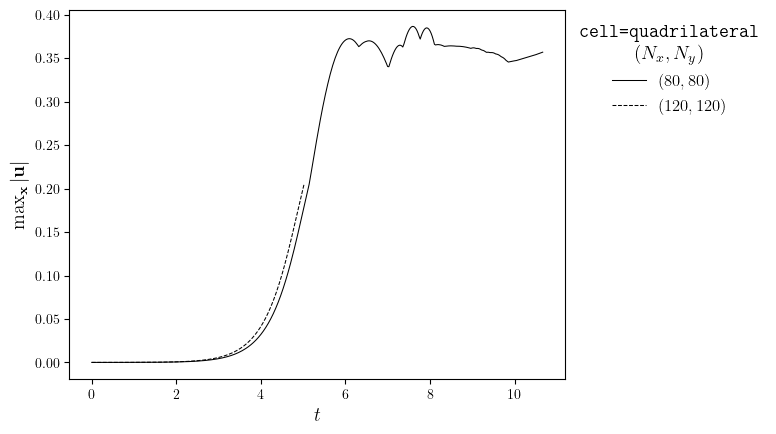

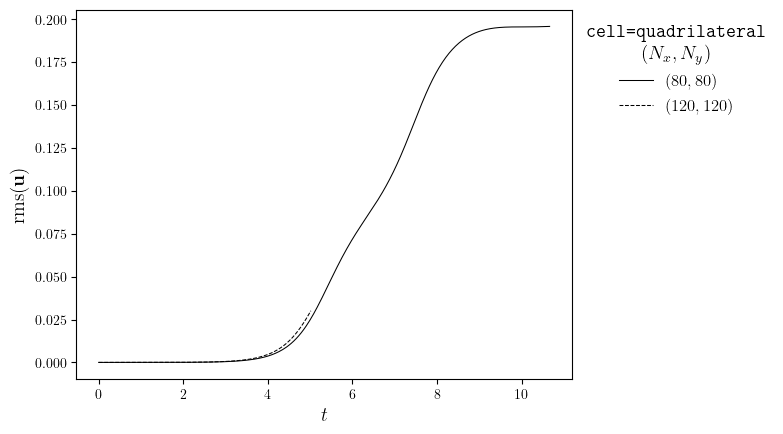

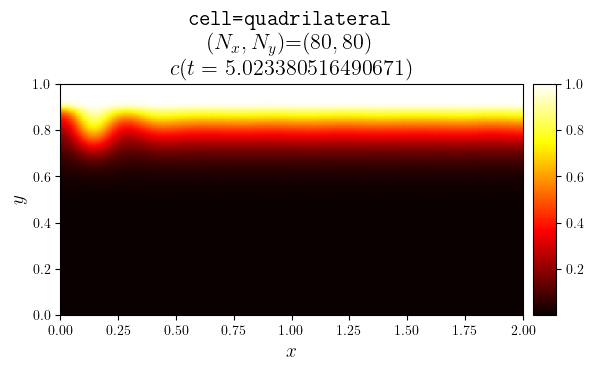

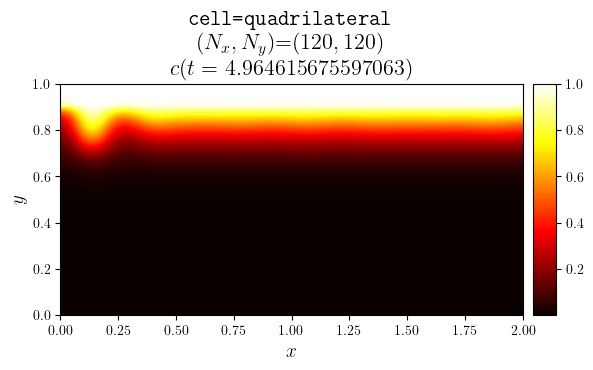

In [2]:
DIR_FIGS = None #f'./figures/{get_ipynb_file_name()}'

cMax_lines, uMax_lines, uRMS_lines, labels = [], [], [], []
legend_title = f'$\\texttt{{cell={CELL_TYPE}}}$\n$(N_x, N_y)$'

cmap_t_target = 5.0
cmap_funcs, cmap_titles, cmap_names = [], [], []

for (Nx, Ny), sim in simulations.items():
    label = f'$({Nx}, {Ny})$'
    labels.append(label)
    cMinMax = sim['cMinMax']
    cMax = cMinMax.sub(1)
    cMax_lines.append((cMax.time_series, cMax.value_series))
    uMinMax = sim['uMinMax']
    uMax = uMinMax.sub(1)
    uMax_lines.append((uMax.time_series, uMax.value_series))
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))
    c = sim['c']
    time_index = as_index(c.time_series, cmap_t_target)
    cmap_funcs.append(c.series[time_index])
    cmap_titles.append(f'{legend_title}$ = ${label}\n$c(t={c.time_series[time_index]})$')
    cmap_names.append(f'c(x,y)__Nx={Nx}|Ny={Ny}')

line_kws = dict(
    cyc='black',
    x_label='$t$',
    legend_labels=labels,
    legend_title=legend_title,
)

fig, ax = plot_line(
    cMax_lines,
    y_label='$\max_{\mathbf{x}} c$',
    y_lims=(0.9, 1.1),
    **line_kws,
)
# save_figure('cMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uMax_lines,
    y_label='$\max_{\mathbf{x}}|\mathbf{u}|$',
    **line_kws,
)
# save_figure('uMax(t)', DIR_FIGS, prefix=False)(fig)

fig, ax = plot_line(
    uRMS_lines,
    y_label='$\mathrm{rms}(\mathbf{u})$',
    **line_kws,
)
# save_figure('uRMS(t)', DIR_FIGS, prefix=False)(fig)

for func, title, name in zip(cmap_funcs, cmap_titles, cmap_names): 
    fig, ax = plot_colormap(func, title=title)
    # save_figure(name, DIR_FIGS, prefix=False)(fig)